In [1]:
import os
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from loaddata import LoadDataset_scar, F_nifity_bboxCrop
from network import Seg_3DNet_2task
from function import F_LoadParam, F_loss_scar

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def dice_binary(pred, target, eps=1e-8, empty_value=np.nan):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)
    pred_sum = np.sum(pred)
    target_sum = np.sum(target)
    if pred_sum == 0 and target_sum == 0:
        return empty_value
    inter = np.sum(pred * target)
    return (2.0 * inter + eps) / (pred_sum + target_sum + eps)

def dice_label(pred_label, gt_label, label_value, empty_value=np.nan):
    pred_bin = (pred_label == label_value).astype(np.float32)
    gt_bin = (gt_label == label_value).astype(np.float32)
    return dice_binary(pred_bin, gt_bin, empty_value=empty_value)

def class_counts(label_map):
    values, counts = np.unique(label_map, return_counts=True)
    return {int(v): int(c) for v, c in zip(values, counts)}

def scar_region_dice(pred_label, gt_label, eps=1e-8, empty_value=np.nan):
    pred_bin = (pred_label > 0).astype(np.float32)
    gt_bin = (gt_label > 0).astype(np.float32)
    return dice_binary(pred_bin, gt_bin, eps=eps, empty_value=empty_value)
def plot_case(result, slice_idx=None):
    image = result["image"]
    gt_LA = result["gt_LA"]
    pred_LA = result["pred_LA"]
    gt_scar = result["gt_scar"]
    pred_scar = result["pred_scar"]

    if slice_idx is None:
        slice_idx = image.shape[-1] // 2

    img2d = image[:, :, slice_idx]
    gt_la2d = gt_LA[:, :, slice_idx]
    pred_la2d = pred_LA[:, :, slice_idx]
    gt_scar2d = gt_scar[:, :, slice_idx]
    pred_scar2d = pred_scar[:, :, slice_idx]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(img2d, cmap="gray")
    axes[0, 0].set_title(f"LGE image (slice {slice_idx})")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(gt_la2d, cmap="gray")
    axes[0, 1].set_title("GT LA")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(pred_la2d, cmap="gray")
    axes[0, 2].set_title("Pred LA")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(img2d, cmap="gray")
    axes[1, 0].set_title("LGE image")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(gt_scar2d, cmap="viridis", vmin=0, vmax=1)
    axes[1, 1].set_title("GT scar labels")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(pred_scar2d, cmap="viridis", vmin=0, vmax=1)
    axes[1, 2].set_title("Pred scar labels")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

def plot_overlay(result, slice_idx=None):
    image = result["image"]
    gt_LA = result["gt_LA"]
    pred_LA = result["pred_LA"]
    gt_scar = result["gt_scar"]
    pred_scar = result["pred_scar"]

    if slice_idx is None:
        slice_idx = image.shape[-1] // 2

    img2d = image[:, :, slice_idx]
    gt_la2d = gt_LA[:, :, slice_idx]
    pred_la2d = pred_LA[:, :, slice_idx]
    gt_scar2d = gt_scar[:, :, slice_idx]
    pred_scar2d = pred_scar[:, :, slice_idx]

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img2d, cmap="gray")
    plt.imshow(np.ma.masked_where(gt_la2d == 0, gt_la2d), alpha=0.4)
    plt.title("Image + GT LA")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(img2d, cmap="gray")
    plt.imshow(np.ma.masked_where(pred_la2d == 0, pred_la2d), alpha=0.4)
    plt.title("Image + Pred LA")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(img2d, cmap="gray")
    plt.imshow(np.ma.masked_where(gt_scar2d == 0, gt_scar2d), cmap="viridis", vmin=0, vmax=1, alpha=0.4)
    plt.title("Image + GT scar")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(img2d, cmap="gray")
    plt.imshow(np.ma.masked_where(pred_scar2d == 0, pred_scar2d), cmap="viridis", vmin=0, vmax=1, alpha=0.4)
    plt.title("Image + Pred scar")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    
def load_cropped_gt_scar(LAlabelname, LAscarMaplabelname):
    # get crop center from LA label, same logic as LoadDataset_scar
    la_nib = nib.load(LAlabelname)
    la = np.asanyarray(la_nib.dataobj).squeeze()

    center_slice = la[:, :, int(la.shape[2] / 2)]
    center_coord = np.floor(np.mean(np.stack(np.where(center_slice > 0)), -1)).astype(np.int16)

    scar_nib = nib.load(LAscarMaplabelname)
    scar = np.asanyarray(scar_nib.dataobj).squeeze()

    scar_crop = F_nifity_bboxCrop(scar, la,margin = 5)
    return scar_crop

def run_one_case_notebook(imagename, LAlabelname, LAscarMaplabelname, model_path, epoch=99):
    # model
    net = Seg_3DNet_2task(1, 1).to(device)
    F_LoadParam(model_path, net)
    net.eval()

    # data from your pipeline
    numpyimage, numpylabel_LA, numpylabel_LAdist, numpyprob_normal, numpyprob_scar = \
        LoadDataset_scar(imagename, LAlabelname, LAscarMaplabelname)

    gt_scar = load_cropped_gt_scar(LAlabelname, LAscarMaplabelname)

    # tensors
    tensorimage = torch.from_numpy(np.array([numpyimage])).float().to(device)
    tensorlabel_LA = torch.from_numpy(np.array([numpylabel_LA > 0]).astype(np.float32)).to(device)
    tensorlabel_LAdist = torch.from_numpy(np.array([numpylabel_LAdist]).astype(np.float32)).to(device)
    tensorprob_normal = torch.from_numpy(np.array([numpyprob_normal]).astype(np.float32)).to(device)
    tensorprob_scar = torch.from_numpy(np.array([numpyprob_scar]).astype(np.float32)).to(device)

    with torch.no_grad():
        output = net(tensorimage)
        out_LA, out_scar = output

        loss_la, loss_sdf_la, loss_scar, loss_scar_m1, loss_scar_m2 = F_loss_scar(
            output, tensorlabel_LA, tensorlabel_LAdist, tensorprob_normal, tensorprob_scar
        )
        weight_sdm = 1e-2 * (1.05 ** (epoch // 10))
        total_loss = loss_la + weight_sdm * loss_sdf_la + 10 * loss_scar

    # predictions
    pred_LA_prob = out_LA.squeeze().cpu().numpy()
    pred_LA = (pred_LA_prob > 0.5).astype(np.uint8)

    pred_scar_prob = out_scar.squeeze(0).cpu().numpy()   # (2,H,W,D)
    pred_scar_prob = pred_scar_prob * (pred_scar_prob > 0.1)
    pred_scar_cls = np.argmax(pred_scar_prob, axis=0)
    pred_scar = ((pred_scar_cls == 1) & (pred_scar_prob[1] > 0.5) & (pred_LA > 0)).astype(np.uint8)

    # GT
    image_crop = numpyimage.squeeze()
    gt_LA = (numpylabel_LA.squeeze() > 0).astype(np.uint8)
    gt_scar = (gt_scar > 0).astype(np.uint8)
    gt_counts = class_counts(gt_scar)
    pred_counts = class_counts(pred_scar)

    # metrics
    dice_la = dice_binary(pred_LA, gt_LA)
    dice_scar_region = scar_region_dice(pred_scar, gt_scar)
    loss_la_value = loss_la.item()
    loss_sdf_la_value = loss_sdf_la.item()
    loss_scar_value = loss_scar.item()
    loss_scar_m1_value = loss_scar_m1.item()
    loss_scar_m2_value = loss_scar_m2.item()
    total_loss_value = total_loss.item()

    print("LA Dice         :", dice_la)
    print("Scar Region Dice:", dice_scar_region)
    print("GT counts       :", gt_counts)
    print("Pred counts     :", pred_counts)
    print("loss_la      :", loss_la_value)
    print("loss_sdf_la  :", loss_sdf_la_value)
    print("loss_scar    :", loss_scar_value)
    print("loss_scar_m1 :", loss_scar_m1_value)
    print("loss_scar_m2 :", loss_scar_m2_value)
    print("total_loss   :", total_loss_value)

    return {
        "image": image_crop,
        "gt_LA": gt_LA,
        "pred_LA": pred_LA,
        "gt_scar": gt_scar,
        "pred_scar": pred_scar,
        "pred_LA_prob": pred_LA_prob,
        "pred_scar_prob": pred_scar_prob,
        "dice_la": dice_la,
        "dice_scar_region": dice_scar_region,
        "loss_la": loss_la_value,
        "loss_sdf_la": loss_sdf_la_value,
        "loss_scar": loss_scar_value,
        "loss_scar_m1": loss_scar_m1_value,
        "loss_scar_m2": loss_scar_m2_value,
        "total_loss": total_loss_value,
    }

In [5]:
model_path = "/work/users/g/s/gsonw/BIOS740/final_project/AJSQ_2/Script_AJSQnet/result_model/net_with_94.pkl"

subject_dir = "/work/users/g/s/gsonw/BIOS740/final_project/LA_scar_quantification/train_data/train_3"

imagename = os.path.join(subject_dir, "enhanced.nii.gz")
LAlabelname = os.path.join(subject_dir, "atriumSegImgMO.nii.gz")
LAscarMaplabelname = os.path.join(subject_dir, "scarSegImgM.nii.gz")

result = run_one_case_notebook(
    imagename,
    LAlabelname,
    LAscarMaplabelname,
    model_path,
    epoch=94,
)


/work/users/g/s/gsonw/BIOS740/final_project/AJSQ_2/Script_AJSQnet/result_model/net_with_94.pkl
LA Dice         : 0.9628364082181502
Scar Region Dice: 2.1340162185187068e-12
GT counts       : {0: 2354610, 1: 4686}
Pred counts     : {0: 2359296}
loss_la      : 0.009463731199502945
loss_sdf_la  : -16.442161560058594
loss_scar    : 0.0017904984997585416
loss_scar_m1 : 0.13727669417858124
loss_scar_m2 : 0.1452137529850006
total_loss   : -0.22770319879055023


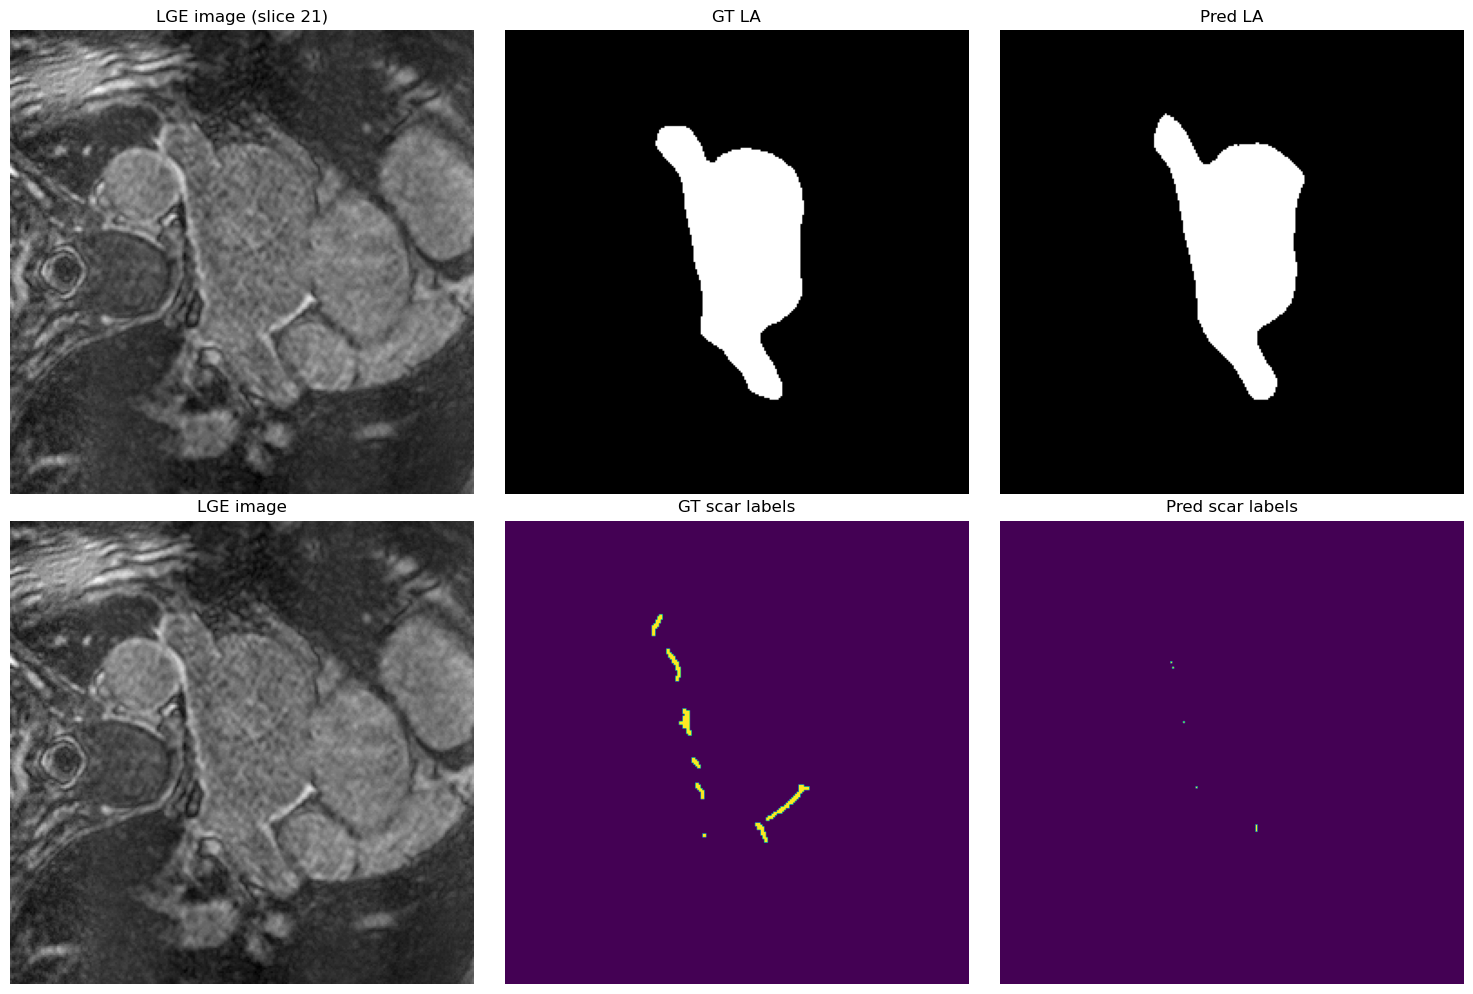

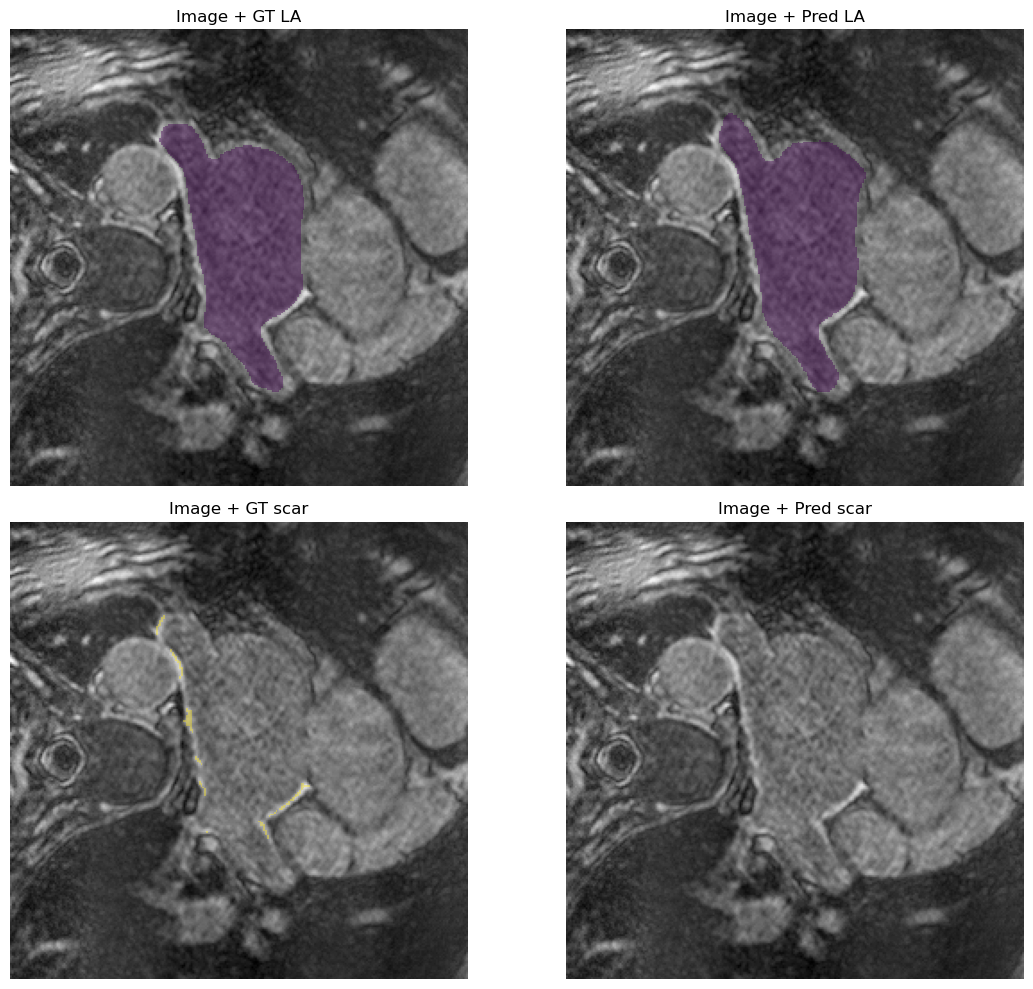

In [4]:
plot_case(result, slice_idx=21)
plot_overlay(result, slice_idx=21)